# Le Lien : analyse de la programmation (sept. 2025 à juin 2026)

Ce notebook reprend l'analyse de données réalisée en équipe pendant le bootcamp IA de DesCodeuses (5 jours), en la corrigeant et en la complétant.

**Questions posées**

1. Quels types d'événements remplissent la salle et lesquels couvrent leurs coûts ?
2. Le délai entre l'annonce d'un événement et sa date a-t-il un lien avec le nombre de billets vendus ?
3. Quelles recommandations concrètes en tirer pour l'association ?

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG = ROOT / "figures"
FIG.mkdir(exist_ok=True)

# Couleurs fixes par type d'événement (palette testée pour le daltonisme)
COULEURS = {"Atelier": "#2a78d6", "Concert": "#eb6834", "Exposition": "#1baf7a"}
ORDRE = ["Atelier", "Concert", "Exposition"]
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "font.size": 10,
})

## 1. Chargement et contrôle qualité

In [2]:
df = pd.read_csv(ROOT / "data/raw/evenements_le_lien.csv", parse_dates=["date"])
print(df.shape)
df.head()

(168, 9)


,date,jour,type_evenement,jauge,billets_vendus,prix_billet,recette,cout_production,delai_annonce_jours
0,2025-09-01,lundi,Exposition,80,50,0,0,320,20
1,2025-09-02,mardi,Exposition,80,53,0,0,320,14
2,2025-09-03,mercredi,Atelier,30,28,8,224,180,19
3,2025-09-05,vendredi,Concert,150,88,14,1232,780,19
4,2025-09-10,mercredi,Atelier,30,25,8,200,180,29


In [3]:
jours = ["lundi", "mardi", "mercredi", "jeudi", "vendredi", "samedi", "dimanche"]
controles = {
    "valeurs manquantes": int(df.isna().sum().sum()),
    "jour incohérent avec la date": int((df["date"].dt.dayofweek.map(dict(enumerate(jours))) != df["jour"]).sum()),
    "recette différente de billets x prix": int((df["billets_vendus"] * df["prix_billet"] != df["recette"]).sum()),
    "billets vendus au-dessus de la jauge": int((df["billets_vendus"] > df["jauge"]).sum()),
    "dates en double": int(df["date"].duplicated().sum()),
}
pd.Series(controles, name="nombre de lignes")

valeurs manquantes                      0
jour incohérent avec la date            0
recette différente de billets x prix    0
billets vendus au-dessus de la jauge    0
dates en double                         1
Name: nombre de lignes, dtype: int64

In [4]:
df[df["date"].duplicated(keep=False)]

,date,jour,type_evenement,jauge,billets_vendus,prix_billet,recette,cout_production,delai_annonce_jours
117,2026-03-20,vendredi,Concert,150,78,14,1092,780,15
118,2026-03-20,vendredi,Concert,400,380,14,5320,1400,32


Les données sont propres, à une exception près : le **20 mars 2026** compte deux concerts, dont un avec une jauge de 400 places, 380 billets vendus et un coût de 1 400 €. Toutes les autres dates de concert ont une jauge de 150.

Il s'agit soit d'un événement exceptionnel (festival, salle extérieure), soit d'une erreur de saisie. Dans les deux cas, cette ligne gonfle fortement les totaux des concerts (+3 920 € de marge à elle seule). **Elle est conservée dans les données mais exclue des analyses ci-dessous**, et signalée à part.

In [5]:
df["remplissage"] = df["billets_vendus"] / df["jauge"]
df["marge"] = df["recette"] - df["cout_production"]
df["mois"] = df["date"].dt.to_period("M")

exceptionnel = df["jauge"] == 400
d = df[~exceptionnel].copy()
print(f"{len(d)} événements analysés, 1 événement exceptionnel mis de côté")

167 événements analysés, 1 événement exceptionnel mis de côté


## 2. Remplissage et rentabilité par type d'événement

In [6]:
synthese = (
    d.groupby("type_evenement")
     .agg(evenements=("date", "size"),
          jauge=("jauge", "first"),
          prix=("prix_billet", "first"),
          remplissage_moyen=("remplissage", "mean"),
          billets_total=("billets_vendus", "sum"),
          recette_totale=("recette", "sum"),
          cout_total=("cout_production", "sum"),
          marge_totale=("marge", "sum"),
          part_deficitaire=("marge", lambda s: (s < 0).mean()))
     .reindex(ORDRE)
)
synthese["taux_couverture"] = synthese["recette_totale"] / synthese["cout_total"]
synthese.style.format({"remplissage_moyen": "{:.0%}", "part_deficitaire": "{:.0%}",
                       "taux_couverture": "{:.0%}", "recette_totale": "{:,.0f} €",
                       "cout_total": "{:,.0f} €", "marge_totale": "{:,.0f} €"})

,evenements,jauge,prix,remplissage_moyen,billets_total,recette_totale,cout_total,marge_totale,part_deficitaire,taux_couverture
type_evenement,,,,,,,,,,
Atelier,43,30,8,82%,1055,"8,440 €","7,740 €",700 €,23%,109%
Concert,81,150,14,42%,5068,"70,952 €","63,180 €","7,772 €",35%,112%
Exposition,43,80,0,50%,1715,0 €,"13,760 €","-13,760 €",100%,0%


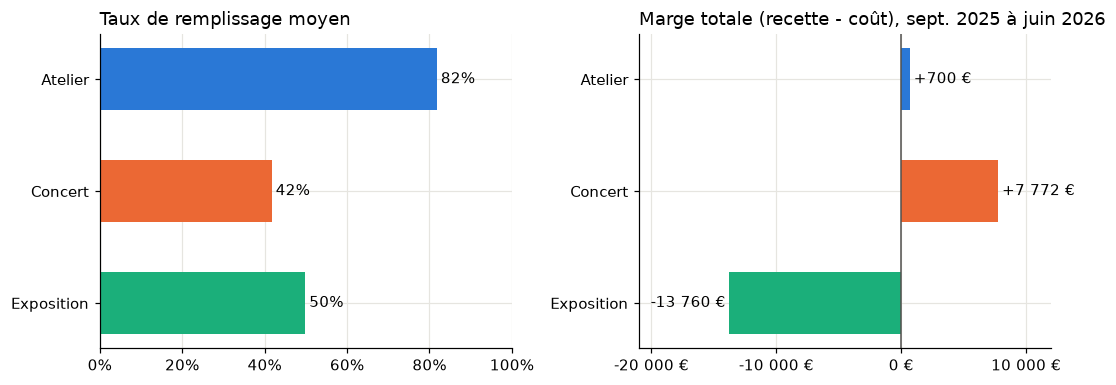

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))

ax = axes[0]
vals = synthese["remplissage_moyen"]
ax.barh(ORDRE, vals, color=[COULEURS[t] for t in ORDRE], height=0.55)
for i, v in enumerate(vals):
    ax.text(v + 0.01, i, f"{v:.0%}", va="center")
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.set_title("Taux de remplissage moyen", loc="left")
ax.invert_yaxis()

ax = axes[1]
vals = synthese["marge_totale"]
ax.barh(ORDRE, vals, color=[COULEURS[t] for t in ORDRE], height=0.55)
for i, v in enumerate(vals):
    ax.text(v + (300 if v >= 0 else -300), i, f"{v:+,.0f} €".replace(",", " "),
            va="center", ha="left" if v >= 0 else "right")
ax.axvline(0, color="#52514e", linewidth=1)
ax.set_xlim(-21000, 12000)
ax.set_xticks([-20000, -10000, 0, 10000])
ax.xaxis.set_major_formatter(lambda x, _: f"{x:,.0f} €".replace(",", " "))
ax.set_title("Marge totale (recette - coût), sept. 2025 à juin 2026", loc="left")
ax.invert_yaxis()

fig.tight_layout()
fig.savefig(FIG / "01_remplissage_marge_par_type.png", bbox_inches="tight")
plt.show()

**Lecture**

- Les **ateliers** sont presque toujours pleins (82 % en moyenne sur 30 places) mais leur marge est faible : 8 € x 30 places = 240 € au maximum pour 180 € de coût.
- Les **concerts** portent la billetterie, mais la salle de 150 places n'est remplie qu'à 42 % en moyenne et **un concert sur trois perd de l'argent**. Le seuil de rentabilité est de 56 billets (780 € / 14 €).
- Les **expositions** sont gratuites : leur coût (320 € chacune, 13 760 € au total) n'est couvert par aucune recette de billetterie. Ce n'est pas forcément un problème (mission culturelle, subventions), mais ces financements ne figurent pas dans les données.

### Correction de la version bootcamp

Le camembert « SUM de cout_production » affichait Atelier 33 % et Concert 67 %, sans les expositions. La répartition réelle des coûts est la suivante (hors événement exceptionnel) :

In [8]:
(d.groupby("type_evenement")["cout_production"].sum() / d["cout_production"].sum()).reindex(ORDRE).map("{:.0%}".format)

type_evenement
Atelier        9%
Concert       75%
Exposition    16%
Name: cout_production, dtype: str

## 3. Délai d'annonce et billets vendus

### Ce qui n'allait pas dans la version bootcamp

L'analyse d'origine calculait une corrélation à partir des **médianes par type** (3 points seulement), puis reliait ces médianes par une courbe. Avec trois points, une corrélation ne veut rien dire, et une courbe entre des catégories suggère une continuité qui n'existe pas.

Ici, on regarde **chaque événement** : le délai d'annonce en abscisse, le taux de remplissage en ordonnée (plutôt que les billets vendus, pour comparer des salles de tailles différentes).

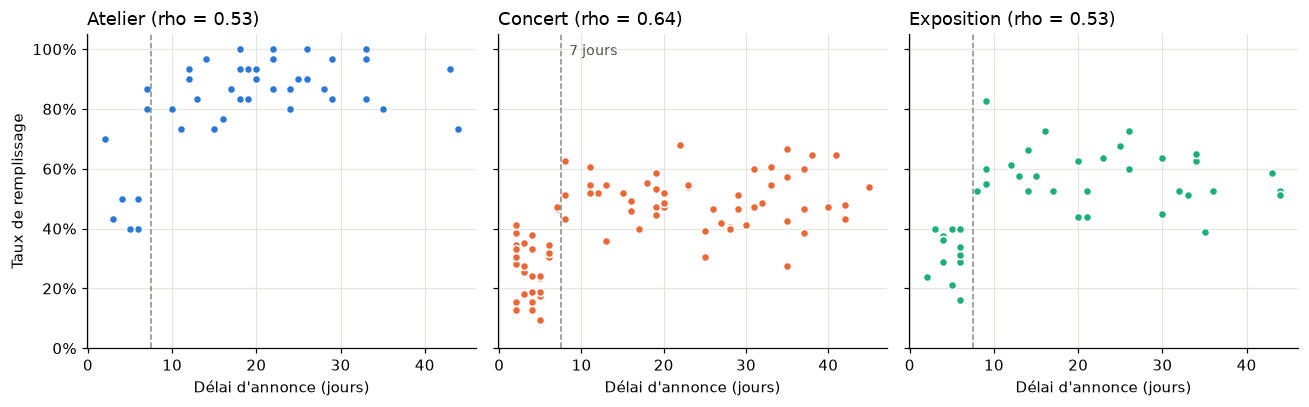

,type,n,rho de Spearman,p-valeur
0,Atelier,43,0.53,2.400941e-04
1,Concert,81,0.64,1.890212e-10
2,Exposition,43,0.53,2.272346e-04


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
resultats = []
for ax, t in zip(axes, ORDRE):
    g = d[d["type_evenement"] == t]
    rho, p = stats.spearmanr(g["delai_annonce_jours"], g["remplissage"])
    resultats.append({"type": t, "n": len(g), "rho de Spearman": round(rho, 2), "p-valeur": p})
    ax.scatter(g["delai_annonce_jours"], g["remplissage"], s=28, color=COULEURS[t],
               edgecolor="white", linewidth=1)
    ax.axvline(7.5, color="#8a8983", linestyle="--", linewidth=1)
    ax.set_title(f"{t} (rho = {rho:.2f})", loc="left")
    ax.set_xlabel("Délai d'annonce (jours)")
axes[0].set_ylabel("Taux de remplissage")
axes[0].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
axes[0].set_ylim(0, 1.05)
axes[1].text(8.5, 0.98, "7 jours", color="#52514e", fontsize=9)
fig.tight_layout()
fig.savefig(FIG / "02_delai_vs_remplissage.png", bbox_inches="tight")
plt.show()
pd.DataFrame(resultats)

Pour les trois types, la corrélation de Spearman est positive et nette (entre 0,53 et 0,64, p < 0,001) : **plus un événement est annoncé tôt, mieux il se remplit**.

Les nuages de points montrent surtout une rupture autour de **7 jours** : en dessous, le remplissage s'effondre ; au-delà, il se stabilise. On le vérifie par tranches de délai.

In [10]:
d["tranche_delai"] = pd.cut(d["delai_annonce_jours"], [0, 7, 14, 21, 60],
                            labels=["7 j ou moins", "8 à 14 j", "15 à 21 j", "22 j et plus"])
tranches = d.pivot_table(index="tranche_delai", columns="type_evenement",
                         values="remplissage", aggfunc="mean", observed=True)[ORDRE]
effectifs = d.pivot_table(index="tranche_delai", columns="type_evenement",
                          values="remplissage", aggfunc="size", observed=True)[ORDRE]
display(tranches.style.format("{:.0%}"))
effectifs

type_evenement,Atelier,Concert,Exposition
tranche_delai,,,
7 j ou moins,57%,28%,32%
8 à 14 j,86%,52%,61%
15 à 21 j,88%,50%,55%
22 j et plus,90%,50%,57%


type_evenement,Atelier,Concert,Exposition
tranche_delai,,,
7 j ou moins,9,30,13
8 à 14 j,6,9,8
15 à 21 j,11,12,7
22 j et plus,17,30,15


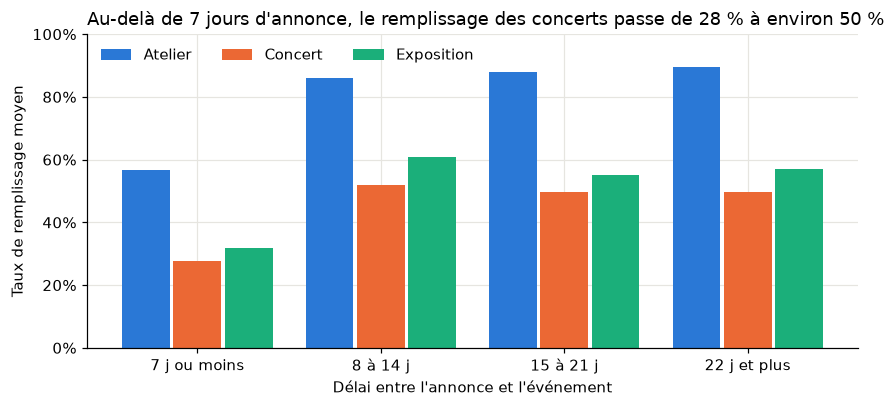

In [11]:
fig, ax = plt.subplots(figsize=(8, 3.8))
x = range(len(tranches.index))
largeur = 0.26
for i, t in enumerate(ORDRE):
    pos = [xi + (i - 1) * (largeur + 0.02) for xi in x]
    ax.bar(pos, tranches[t], width=largeur, color=COULEURS[t], label=t)
ax.set_xticks(list(x), tranches.index)
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.0%}")
ax.set_ylim(0, 1)
ax.set_ylabel("Taux de remplissage moyen")
ax.set_xlabel("Délai entre l'annonce et l'événement")
ax.legend(frameon=False, ncol=3, loc="upper left")
ax.set_title("Au-delà de 7 jours d'annonce, le remplissage des concerts passe de 28 % à environ 50 %", loc="left")
fig.tight_layout()
fig.savefig(FIG / "03_remplissage_par_tranche_delai.png", bbox_inches="tight")
plt.show()

## 4. Focus concerts : le délai d'annonce décide de la rentabilité

In [12]:
concerts = d[d["type_evenement"] == "Concert"].copy()
seuil = concerts["cout_production"].iloc[0] / concerts["prix_billet"].iloc[0]
concerts["annonce"] = pd.cut(concerts["delai_annonce_jours"], [0, 7, 60],
                             labels=["7 jours ou moins", "plus de 7 jours"])
focus = concerts.groupby("annonce", observed=True).agg(
    concerts=("date", "size"),
    billets_moyens=("billets_vendus", "mean"),
    part_deficitaire=("marge", lambda s: (s < 0).mean()),
    marge_moyenne=("marge", "mean"),
    marge_totale=("marge", "sum"),
)
print(f"Seuil de rentabilité d'un concert : {seuil:.1f} billets")
focus.style.format({"billets_moyens": "{:.0f}", "part_deficitaire": "{:.0%}",
                    "marge_moyenne": "{:+.0f} €", "marge_totale": "{:+,.0f} €"})

Seuil de rentabilité d'un concert : 55.7 billets


,concerts,billets_moyens,part_deficitaire,marge_moyenne,marge_totale
annonce,,,,,
7 jours ou moins,30,41,83%,-200 €,"-5,998 €"
plus de 7 jours,51,75,6%,+270 €,"+13,770 €"


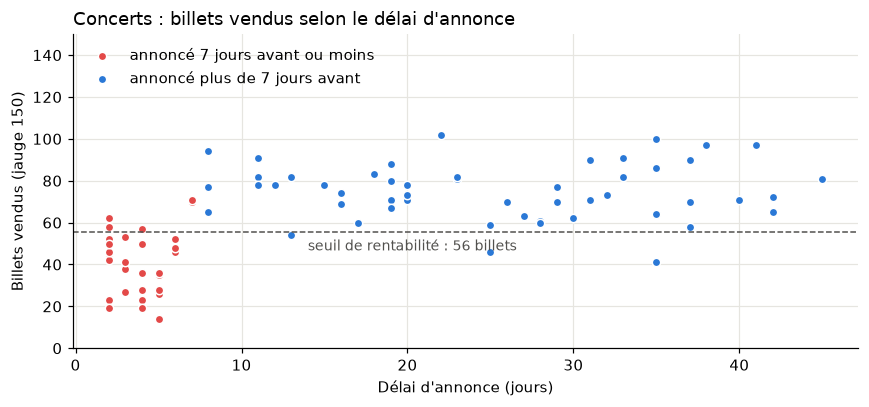

In [13]:
fig, ax = plt.subplots(figsize=(8, 3.8))
court = concerts["delai_annonce_jours"] <= 7
ax.scatter(concerts.loc[court, "delai_annonce_jours"], concerts.loc[court, "billets_vendus"],
           s=30, color="#e34948", edgecolor="white", linewidth=1, label="annoncé 7 jours avant ou moins")
ax.scatter(concerts.loc[~court, "delai_annonce_jours"], concerts.loc[~court, "billets_vendus"],
           s=30, color="#2a78d6", edgecolor="white", linewidth=1, label="annoncé plus de 7 jours avant")
ax.axhline(seuil, color="#52514e", linestyle="--", linewidth=1)
ax.text(14, seuil - 9, f"seuil de rentabilité : {seuil:.0f} billets", ha="left", color="#52514e", fontsize=9)
ax.set_xlabel("Délai d'annonce (jours)")
ax.set_ylabel("Billets vendus (jauge 150)")
ax.set_ylim(0, 150)
ax.legend(frameon=False, loc="upper left")
ax.set_title("Concerts : billets vendus selon le délai d'annonce", loc="left")
fig.tight_layout()
fig.savefig(FIG / "04_concerts_seuil_rentabilite.png", bbox_inches="tight")
plt.show()

Sur les 30 concerts annoncés **7 jours ou moins** à l'avance, 25 sont déficitaires (41 billets vendus en moyenne, -6 000 € au total). Sur les 51 concerts annoncés plus tôt, seuls 3 le sont (75 billets en moyenne, +13 770 € au total).

Autrement dit, les concerts sont rentables dans leur ensemble, et c'est l'annonce tardive qui fait perdre l'essentiel de la marge.

## 5. Évolution mensuelle

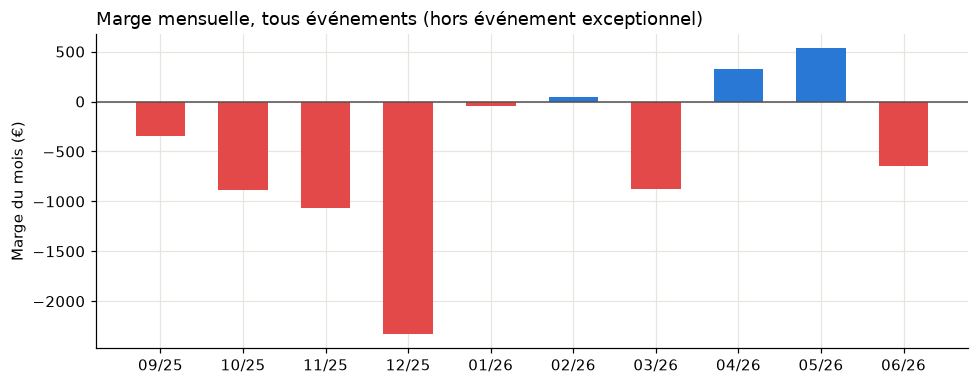

,marge,part_annonces_tardives
mois,,
2025-09,-350 €,31%
2025-10,-882 €,38%
2025-11,"-1,062 €",29%
2025-12,"-2,326 €",53%
2026-01,-40 €,24%
2026-02,+44 €,17%
2026-03,-876 €,25%
2026-04,+322 €,12%
2026-05,+532 €,38%


In [14]:
mensuel = d.groupby("mois").agg(marge=("marge", "sum"),
                                part_annonces_tardives=("delai_annonce_jours", lambda s: (s <= 7).mean()))
fig, ax = plt.subplots(figsize=(9, 3.6))
couleurs = ["#2a78d6" if m >= 0 else "#e34948" for m in mensuel["marge"]]
ax.bar(mensuel.index.strftime("%m/%y"), mensuel["marge"], color=couleurs, width=0.6)
ax.axhline(0, color="#52514e", linewidth=1)
ax.set_ylabel("Marge du mois (€)")
ax.set_title("Marge mensuelle, tous événements (hors événement exceptionnel)", loc="left")
fig.tight_layout()
fig.savefig(FIG / "05_marge_mensuelle.png", bbox_inches="tight")
plt.show()
mensuel.style.format({"marge": "{:+,.0f} €", "part_annonces_tardives": "{:.0%}"})

In [15]:
rho, p = stats.spearmanr(mensuel["part_annonces_tardives"], mensuel["marge"])
print(f"Mois avec beaucoup d'annonces tardives et marge du mois : rho = {rho:.2f} (p = {p:.3f}, 10 mois)")

Mois avec beaucoup d'annonces tardives et marge du mois : rho = -0.47 (p = 0.174, 10 mois)


Décembre 2025 est le mois le plus déficitaire. Les mois où la part d'annonces tardives est forte ont tendance à avoir une marge plus faible (rho = -0,47), mais sur 10 mois ce lien n'est pas significatif (p = 0,17). C'est l'analyse par événement (parties 3 et 4) qui porte la conclusion.

## 6. Recommandations

1. **Annoncer chaque concert au moins 8 jours à l'avance**, idéalement 2 à 3 semaines. C'est le levier le plus net et le moins coûteux mis en évidence par les données.
2. **Suivre le seuil de 56 billets par concert** : un point de billetterie 7 jours avant permet de relancer la communication (newsletter, réseaux) quand les ventes sont en retard.
3. **Ateliers** : ils sont souvent complets. Une hausse modérée du prix (par exemple 10 € au lieu de 8 €) ou une seconde session les jours pleins améliorerait la marge sans risque apparent sur la fréquentation. À tester, les données ne disent rien sur la sensibilité au prix.
4. **Expositions** : les assumer comme un investissement culturel et documenter leur financement (subventions, adhésions, bar), qui n'apparaît pas dans ce jeu de données.

Ces recommandations rejoignent le projet de refonte du site : une page Programmation mise à jour tôt et une newsletter visible sont les outils concrets pour allonger le délai d'annonce.

## 7. Limites

- **Corrélation n'est pas causalité** : les concerts annoncés tôt sont peut-être aussi ceux d'artistes plus connus. Le type d'artiste, le genre musical et le budget communication ne sont pas dans les données.
- **Données de travail fournies pour l'exercice** sur une seule saison (168 événements) : pas de comparaison d'une année sur l'autre.
- **Pas de données de financement** hors billetterie (subventions, adhésions, bar), donc la marge calculée ici n'est pas le résultat financier de l'association.
- L'événement du 20 mars 2026 (jauge 400) mériterait d'être vérifié à la source.